In [1]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

## Flavor

[ 1  8 19 30 38 42 46 53]
[0.01666667 0.11666667 0.18333333 0.18333333 0.13333333 0.06666667
 0.06666667 0.11666667]
0.11041666666666666
[1.6, np.float64(1.4995833333333335), np.float64(1.5179166666666668), np.float64(1.4645833333333333), np.float64(1.4395833333333334), np.float64(1.4379166666666667), np.float64(1.4679166666666668), np.float64(1.4412500000000001), np.float64(1.3329166666666667), np.float64(1.37125), np.float64(1.3129166666666667), np.float64(1.2995833333333333), np.float64(1.33125), np.float64(1.3845833333333335), np.float64(1.2595833333333335), np.float64(1.3745833333333335), np.float64(1.2629166666666667), np.float64(1.1995833333333334), np.float64(1.22625), np.float64(1.2379166666666668), np.float64(1.20625), np.float64(0.42624999999999996), np.float64(0.4595833333333333), np.float64(0.41124999999999995), np.float64(0.36125), np.float64(0.40458333333333335), np.float64(0.38958333333333334), np.float64(0.35458333333333336), np.float64(0.39291666666666664), np.float64

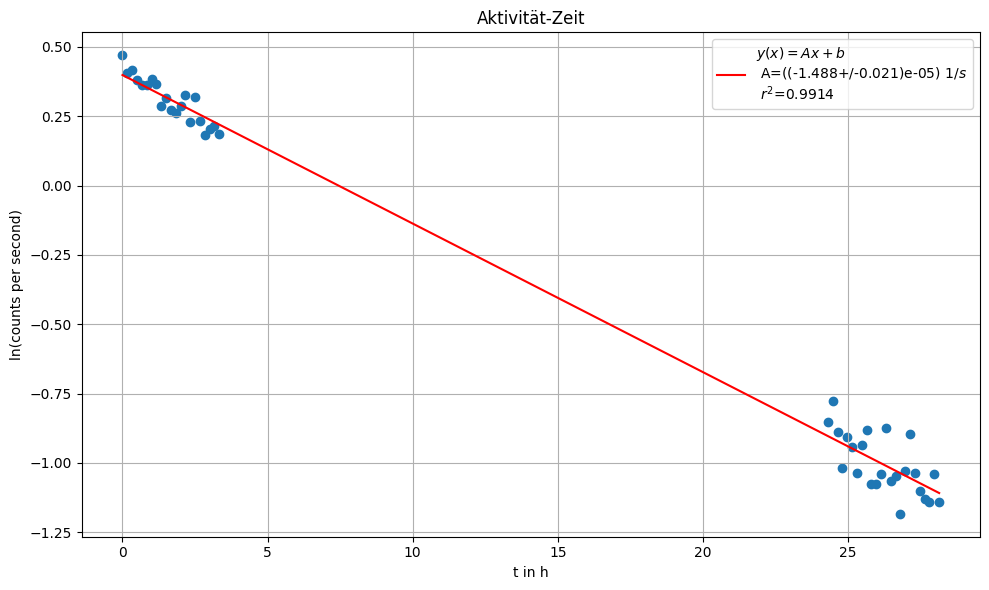

In [22]:
# 1 Hintergrund und Halbwertszeit

# 1.2 Hintergrund
H_Data = pd.read_csv("Hintergrund.csv", sep=',', decimal='.')

H_counts_abs = H_Data["counts"].to_numpy() # alle 60 s
print(H_counts_abs)
H_counts_per = np.array([1/60,0,0,0,0,0,0,0])
for i in range(8):
    if i > 0:
        H_counts_per[i] = (H_counts_abs[i]-H_counts_abs[i-1])/60

print(H_counts_per)

H_counts = np.mean(H_counts_per)
print(H_counts)
#1.3 Halbwertszeit
# Data
Data = pd.read_csv("overtime.csv", sep=',', decimal='.')

counts = Data["counts"].to_numpy()
t = Data["Time since 1970-01-01T00:00:00Z"].to_numpy()-1773058875.825965
counts_rea = ([1.6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.6,0.6,0.01,0.01,0.01,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])

for i in range(45):
    if i > 0 and i != 21:
        counts_rea[i] = (counts[i]-counts[i-1])/600-H_counts
    elif i == 21:
        counts_rea[i] = counts[i]/600-H_counts


t = t/3600
print(counts_rea)
counts_rea = np.log(counts_rea)
# Fit
def Fit(x, a, b):
    return a*x+b

popt, pcov = curve_fit(Fit, t, counts_rea, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(t), max(t), 100)
y_model = Fit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

a = ufloat(a_opt, perr[0])/3600

r2 = Helper.r2_curve_fit(popt, t, counts_rea, Fit)

# Rechnung
tau = 1/a
print(f"tau = {tau}")

T_2 = 0.69314718/a
print(f"T_(1/2) = {T_2}")


plt.figure(figsize=(10, 6))
plt.scatter(t, counts_rea)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({a}) $1/s$ \n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"ln(counts per second)")
plt.xlabel(r"t in h")
plt.legend()
plt.title("Aktivität-Zeit")
plt.tight_layout()
plt.grid()
plt.show()

## Flavor


[-39.16315789 -35.14736842 -31.13157895 -27.11578947 -23.1
 -19.08421053 -15.06842105 -11.05263158  -7.03684211  -3.02105263
   0.99473684   5.01052632   9.02631579  13.04210526  17.05789474
  21.07368421  25.08947368  29.10526316  33.12105263  37.13684211
  41.15263158  45.16842105  49.18421053  53.2         57.21578947
  61.23157895  65.24736842  69.26315789  73.27894737  77.29473684
  81.31052632  85.32631579  89.34210526  93.35789474  97.37368421
 101.38947368 105.40526316 109.42105263 113.43684211 117.45263158
 121.46842105 125.48421053 129.5        133.51578947 137.53157895
 141.54736842 145.56315789 149.57894737 153.59473684 157.61052632
 161.62631579 165.64210526 169.65789474 173.67368421 177.68947368
 181.70526316 185.72105263 189.73684211 193.75263158 197.76842105
 201.78421053 205.8        209.81578947 213.83157895 217.84736842
 221.86315789 225.87894737 229.89473684 233.91052632 237.92631579
 241.94210526 245.95789474 249.97368421 253.98947368 258.00526316
 262.02105263 266

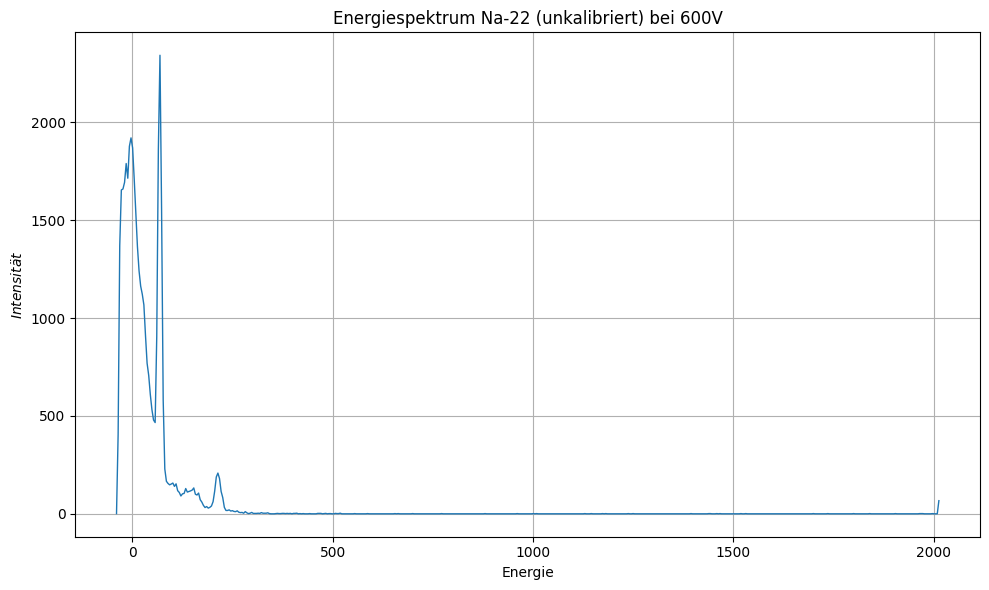

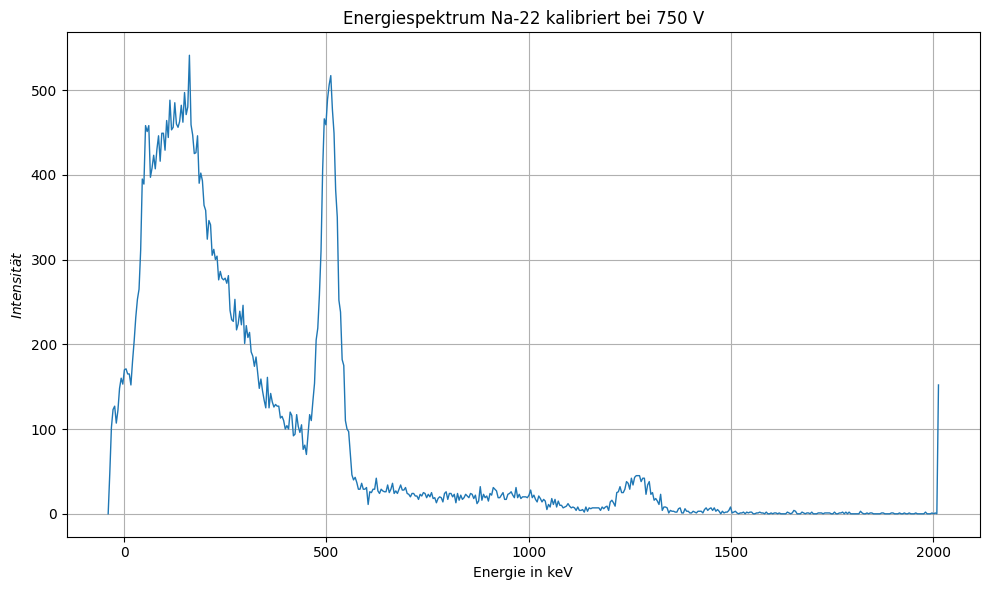

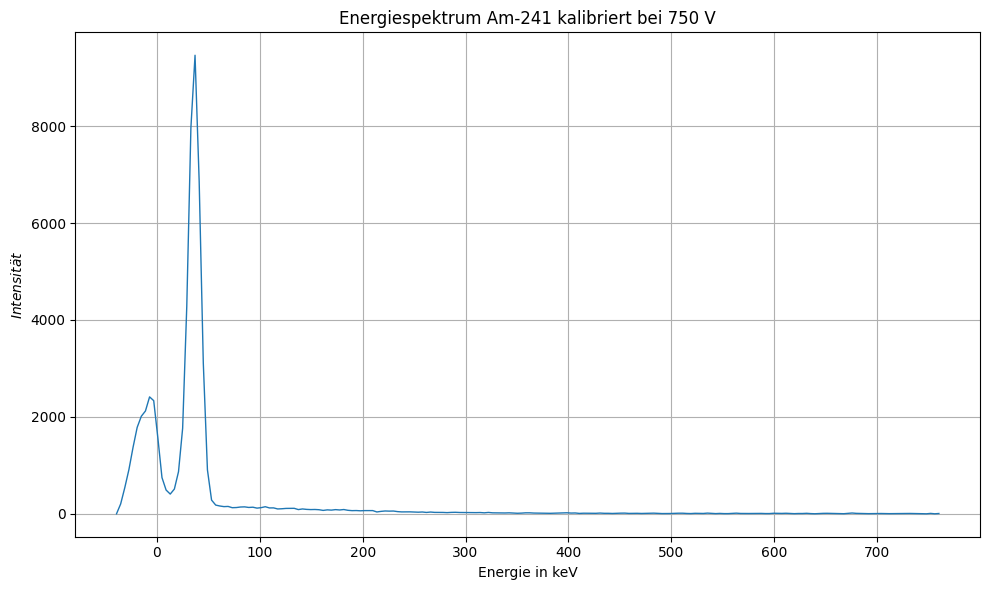

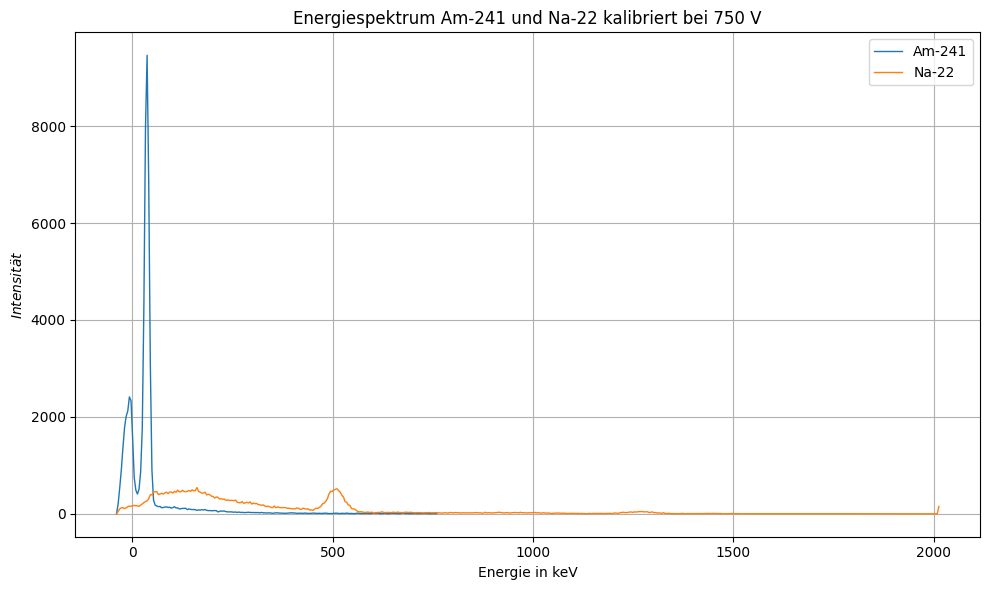

In [ ]:
# Spektrum

# Data
x = 11  # Abstand für alle Proben in cm
a = x-1


#Spektrum


Spektrum_600 = pd.read_csv("600-V-Na-2.csv", sep=';', decimal=',')

E_600 = Spektrum_600["Energie E_A / keV"].to_numpy()


N_600 = Spektrum_600["Ereignisse N_A"].to_numpy()



# mask = np.isfinite(E) & np.isfinite(N)
# E, N = E[mask], N[mask]


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(E_600, N_600, '-', linewidth=1)
plt.xlabel("Energie")
plt.ylabel("$Intensität$")
plt.title("Energiespektrum Na-22 (unkalibriert) bei 600V")
plt.grid()
plt.tight_layout()


# new Data

Spektrum_Na = pd.read_csv("750-V-Na.csv", sep=';', decimal=',')

E_Na = Spektrum_Na["Energie E_A / keV"].to_numpy()


N_Na = Spektrum_Na["Ereignisse N_A"].to_numpy()



# mask = np.isfinite(E) & np.isfinite(N)
# E, N = E[mask], N[mask]


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(E_Na, N_Na, '-', linewidth=1)
plt.xlabel("Energie in keV")
plt.ylabel("$Intensität$")
plt.title("Energiespektrum Na-22 kalibriert bei 750 V")
plt.grid()
plt.tight_layout()

# new Data
Spektrum_Am = pd.read_csv("750-V-Am.csv", sep=';', decimal=',')

E = Spektrum_Am["Energie E_A / keV"].to_numpy()[:200]
print(E)

N = Spektrum_Am["Ereignisse N_A"].to_numpy()[:200]
print(type(N[0]))
print(N[0])


# mask = np.isfinite(E) & np.isfinite(N)
# E, N = E[mask], N[mask]


# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(E, N, '-', linewidth=1)
plt.xlabel("Energie in keV")
plt.ylabel("$Intensität$")
plt.title("Energiespektrum Am-241 kalibriert bei 750 V")
plt.grid()
plt.tight_layout()


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(E, N, '-', linewidth=1, label="Am-241")
plt.plot(E_Na, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("Energie in keV")
plt.ylabel("$Intensität$")
plt.title("Energiespektrum Am-241 und Na-22 kalibriert bei 750 V")
plt.grid()
plt.legend()
plt.tight_layout()

## Flavor


In [ ]:
# Abstandsgesetz

#Data

r = np.array([2.70, 3.68, 4.67, 5.66, 6.80, 7.71, 8.73, 10.74, 13.73])    #Abstand +/- 0.01 in cm bzw. +/- 0.005 cm
counts = np.array([6360, 3307, 2145, 1500, 1011, 788, 663, 429, 241])   #counts pro 100s

x = 1/r**2

x_err = 1/ufloat(1,0.01)**2
print(x_err)

# Fit
def Fit(x, a, b):
    return a*x+b

popt, pcov = curve_fit(Fit, x, counts,sigma=0.002, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(x), max(x), 100)
y_model = Fit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))

a = ufloat(a_opt, perr[0])
print(b_opt)

r2 = Helper.r2_curve_fit(popt, x, counts, Fit)

# Graph (error-bars)
plt.figure(figsize=(10, 6))
plt.scatter(x, counts)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({a}) $1/s$ \n $r^2$={r2:.4f}")
plt.errorbar(x, counts, fmt='o',xerr=0.002, capsize=3, markersize=4)
# plt.plot(V, p, "o")
plt.ylabel(r"counts per 100 seconds")
plt.xlabel(r"1/r²")
plt.legend()
plt.title("Aktivität-Abstand")
plt.tight_layout()
plt.grid()
plt.show()


1.000+/-0.020


NameError: name 'b' is not defined